# Lab 01 – Phân tích khám phá dữ liệu (EDA)

**Mục tiêu buổi lab:**
- Nắm các bước EDA: thống kê mô tả, xử lý dữ liệu, trực quan hóa, phân tích đơn biến & hai biến.
- Thực hành trên các bộ dữ liệu thực tế (COVID, Marketing Campaign, Housing, Penguins).
- Làm quen với công cụ EDA tự động (ydata_profiling, D-Tale).

**Tệp dữ liệu được dùng (hãy đặt trong đúng thư mục):**
- `covid-data.csv`
- `data/marketing_campaign.csv`
- `data/HousingPricesData.csv`
- `data/penguins_size.csv`

> **Gợi ý:** Nếu chạy lần đầu, bạn có thể cần cài thêm một số thư viện (xem khối cài đặt bên dưới).

## Cài đặt thư viện (tùy chọn)
Mục tiêu: đảm bảo môi trường có đủ các gói cần thiết để chạy toàn bộ notebook.

**Vì sao chạy?** Một số máy chưa có sẵn `ydata_profiling`/`dtale`. Chạy một lần là đủ.

> Có thể bỏ qua nếu đã cài sẵn.

In [ ]:
#!pip install ydata-profiling dtale seaborn matplotlib scipy pandas numpy

## 1.1 Thống kê mô tả (Descriptive Statistics)
**Mục tiêu:** Tính nhanh các thước đo trung tâm & phân tán để hiểu đặc điểm dữ liệu.

**Vì sao chạy?** Đây là bước EDA nền tảng để:
- Nắm kích thước dữ liệu, kiểu dữ liệu, phân bố biến chính (ví dụ: `new_cases`).
- Phát hiện bất thường (giá trị âm/ngoại lai/thiếu) trước khi mô hình hóa.

**Kỳ vọng kết quả:** Các biến như mean/median/mode, variance/std, percentile/quartiles/IQR.

### Bài toán 1
Thực hiện các nhiệm vụ trong bài toán 1 để làm quen với các thao tác cần làm để khám phá 
dữ liệu

#### Nhiệm vụ 1. Khám phá dữ liệu Covid

In [5]:
import pandas as pd
import numpy as np
from scipy import stats

covid_data = pd.read_csv("covid-data.csv", low_memory=False)

# Chuẩn hoá: bỏ khoảng trắng, viết thường
covid_data.columns = covid_data.columns.str.strip()

# Map các tên cột "thực tế" -> tên cột "chuẩn" theo Lab
rename_map = {}
if 'country' in covid_data.columns:
    rename_map['country'] = 'location'
if 'code' in covid_data.columns:
    rename_map['code'] = 'iso_code'

covid_data = covid_data.rename(columns=rename_map)

# Chỉ giữ các cột có sẵn (tránh KeyError nếu file khác cấu trúc)
want = ['iso_code','continent','location','date','total_cases','new_cases']
have = [c for c in want if c in covid_data.columns]
covid_data = covid_data[have]

display(covid_data.head())
print(covid_data.dtypes)
print("Shape:", covid_data.shape)

# (phần thống kê mô tả)
if 'new_cases' in covid_data.columns:
    data_mean = np.mean(covid_data["new_cases"])
    data_median = np.median(covid_data["new_cases"])
    data_mode = stats.mode(covid_data["new_cases"], keepdims=True)
    data_variance = np.var(covid_data["new_cases"])
    data_sd = np.std(covid_data["new_cases"])
    data_max = np.max(covid_data["new_cases"])
    data_min = np.min(covid_data["new_cases"])
    data_percentile = np.percentile(covid_data["new_cases"], 60)
    data_quartile = np.quantile(covid_data["new_cases"], 0.75)
    data_IQR = stats.iqr(covid_data["new_cases"], nan_policy='omit')

    print("Mean:", data_mean)
    print("Median:", data_median)
    print("Mode:", data_mode.mode[0] if hasattr(data_mode, 'mode') else data_mode)
    print("Variance:", data_variance)
    print("Std Dev:", data_sd)
    print("Max:", data_max, "| Min:", data_min)
    print("60th percentile:", data_percentile)
    print("Q3:", data_quartile)
    print("IQR:", data_IQR)
else:
    print("Cột 'new_cases' không có trong file hiện tại. Hãy kiểm tra header hoặc dùng file OWID gốc.")


,iso_code,continent,location,date,total_cases,new_cases
0,AFG,Asia,Afghanistan,2020-01-01,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-02,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-03,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-04,0.0,0.0
4,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0


iso_code        object
continent       object
location        object
date            object
total_cases    float64
new_cases      float64
dtype: object
Shape: (530292, 6)
Mean: 10590.082678546372
Median: nan
Mode: 0.0
Variance: 13834902307.943613
Std Dev: 117621.86152218308
Max: 8401906.0 | Min: 0.0
60th percentile: nan
Q3: nan
IQR: 64.0


> **Lưu ý sư phạm:**
- `median` ít bị ảnh hưởng bởi ngoại lai hơn `mean` → nên kiểm tra cả hai.
- `IQR = Q3 - Q1` hữu ích để phát hiện ngoại lai (rule-of-thumb: điểm nằm ngoài `[Q1-1.5*IQR, Q3+1.5*IQR]`).

#### Nhiệm vụ 2. Khám phá & xử lý dữ liệu Marketing Campaign
**Mục tiêu:** Làm sạch dữ liệu: bỏ trùng, thay thế giá trị, đổi kiểu dữ liệu, xử lý thiếu.

**Vì sao chạy?** Dữ liệu thực tế thường bẩn: trùng lặp, NA, kiểu sai; cần chuẩn hóa trước khi phân tích/ML.

**Kỳ vọng kết quả:** Dữ liệu sạch hơn, sẵn sàng cho thống kê & mô hình hóa.

#### Bài tập thực hành 1
Thực hiện thống kê mô tả trên tập dữ liệu về phân loại chất lượng rượu đỏ. 
Dữ liệu lấy tại https://www.kaggle.com/code/eisgandar/red-wine-quality-eda-classification


In [1]:
# --- Paths (đổi nếu cần) ---
WINE_PATH = "winequality-red.csv"   # hoặc "winequality-red.csv"

import pandas as pd
import numpy as np
from scipy import stats

# 1) Nạp dữ liệu (file Kaggle thường phân cách ; )
wine = pd.read_csv(WINE_PATH, sep=";")
# Chuẩn hoá tên cột (an toàn)
wine.columns = wine.columns.str.strip().str.replace(r"\s+", "_", regex=True).str.lower()

# 2) Kiểm tra nhanh
display(wine.head())
display(wine.info())
print("Missing values per column:\n", wine.isna().sum())

# 3) Thống kê mô tả cơ bản
desc = wine.describe().T
desc["variance"] = wine.var(numeric_only=True)
desc["iqr"] = wine.quantile(0.75, numeric_only=True) - wine.quantile(0.25, numeric_only=True)
display(desc)

# 4) Ví dụ tính riêng trên 1 biến mục tiêu "quality"
q = wine["quality"]
print(
    "quality -> mean:", q.mean(),
    "| median:", q.median(),
    "| mode:", q.mode().iloc[0],
    "| std:", q.std(),
    "| var:", q.var(),
    "| min:", q.min(),
    "| max:", q.max(),
)
print("60th percentile:", np.percentile(q, 60))
print("IQR:", stats.iqr(q, nan_policy="omit"))


,"fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality"
0,"7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0...."
1,"7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.2,0...."
2,"7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0..."
3,"11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,..."
4,"7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0...."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 1 columns):
 #   Column                                                                                                                                             Non-Null Count  Dtype 
---  ------                                                                                                                                             --------------  ----- 
 0   fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality  1599 non-null   object
dtypes: object(1)
memory usage: 12.6+ KB


None

Missing values per column:
 fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality    0
dtype: int64


,count,unique,top,freq,variance,iqr
"fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality",1599,1359,"7.5,0.51,0.02,1.7,0.084,13.0,31.0,0.9953799999...",4,NaN,NaN


KeyError: 'quality'

#### Bài tập thực hành 2
Thực hiện thống kê mô tả trên tập dữ liệu về bệnh tiểu đường. Dữ liệu lấy tại
https://www.kaggle.com/code/vincentlugat/pima-indians-diabetes-eda-prediction-0-906


In [20]:

import pandas as pd

# Load dataset
marketing_data = pd.read_csv("marketing_campaign.csv")
marketing_data = marketing_data[['ID','Year_Birth', 'Education',
                                 'Marital_Status','Income','Kidhome', 'Teenhome',
                                 'Dt_Customer', 'Recency','NumStorePurchases',
                                 'NumWebVisitsMonth']]

# Xem nhanh & loại trùng
display(marketing_data.head())
marketing_data_duplicate = marketing_data.drop_duplicates()
print("Original shape:", marketing_data.shape, " | After drop_duplicates:", marketing_data_duplicate.shape)

# Ví dụ xóa 1 dòng theo index (minh họa)
_ = marketing_data.drop(labels=[1], axis=0)

# Ví dụ xóa 1 cột (minh họa)
_ = marketing_data.drop(labels=['Year_Birth'], axis=1)

# Thay thế giá trị: ánh xạ Teenhome -> has/no teen (đơn giản hóa phân tích)
marketing_data['Teenhome_replaced'] = marketing_data['Teenhome'].replace([0,1,2],
                                                                         ['has no teen','has teen','has teen'])

# Xử lý thiếu & đổi kiểu dữ liệu
marketing_data['Income'] = marketing_data['Income'].fillna(0)
marketing_data['Income_changed'] = marketing_data['Income'].astype(int)

# Kiểm tra thiếu
display(marketing_data.isnull().sum())

# Tạo phiên bản không còn NA (nếu cần thống kê nghiêm ngặt)
marketing_data_withoutna = marketing_data.dropna(how='any')
print("Shape without NA:", marketing_data_withoutna.shape)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,NumStorePurchases,NumWebVisitsMonth
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,4,7
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,2,5
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,10,4
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,4,6
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,6,5


Original shape: (2240, 11)  | After drop_duplicates: (2240, 11)


ID                   0
Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
Recency              0
NumStorePurchases    0
NumWebVisitsMonth    0
Teenhome_replaced    0
Income_changed       0
dtype: int64

Shape without NA: (2240, 13)


## 1.2 Xử lý và trực quan hóa dữ liệu

> **Lưu ý sư phạm:**
- Không bắt buộc luôn `fillna(0)` cho biến thu nhập—hãy cân nhắc: 0 có ý nghĩa hay dùng median/mean/imputation khác.
- Việc tạo thêm cột `_changed` giúp giữ lại giá trị gốc để so sánh & audit.

### Bài toán 1
Thực hiện các nhiệm vụ trong bài toán để làm quen với các công cụ trực quan hóa dữ liệu

####  Nhiệm vụ 1. Trực quan hóa dữ liệu với Matplotlib – Housing Prices
**Mục tiêu:** Vẽ các biểu đồ cột để so sánh top khu vực có giá nhà cao và giá/m².

**Vì sao chạy?** Hình ảnh hóa giúp lộ rõ mẫu & ngoại lệ, hỗ trợ truyền đạt kết quả trực quan.

**Kỳ vọng kết quả:** 3 trường hợp: cơ bản, nâng cao có tiêu đề/nhãn, và so sánh 2 góc nhìn song song.

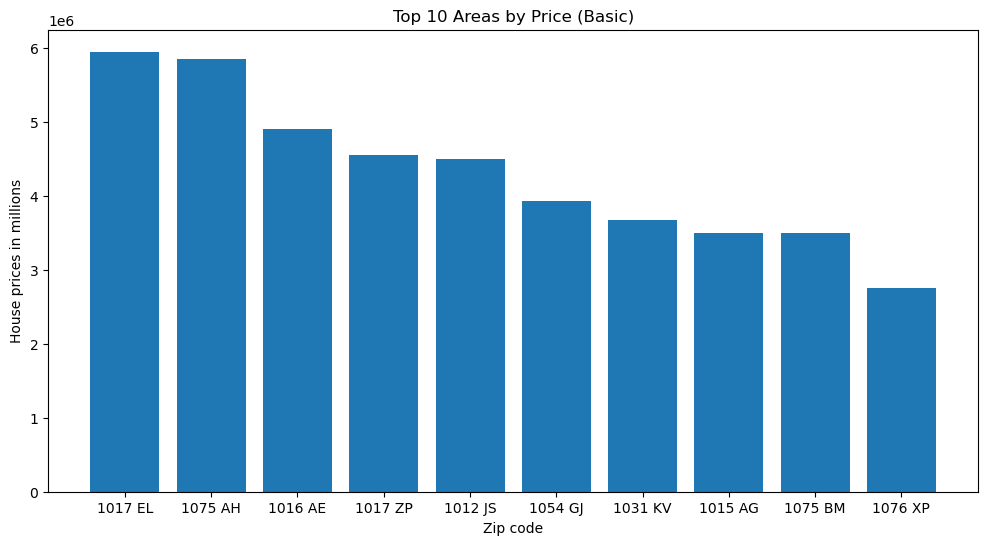

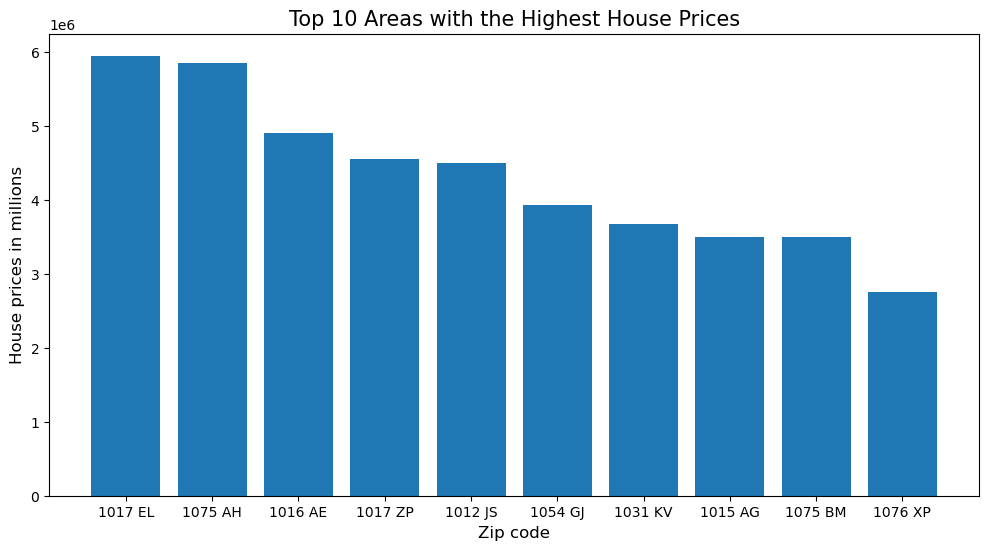

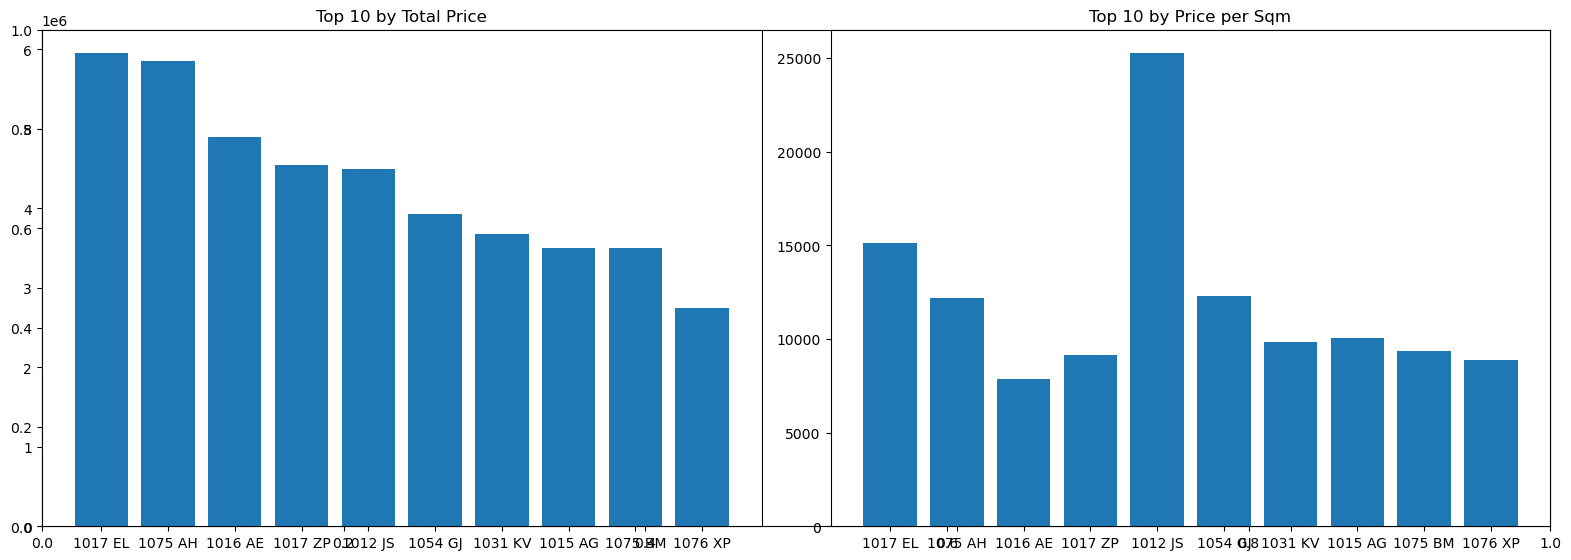

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

houseprices_data = pd.read_csv("HousingPricesData.csv")
houseprices_data = houseprices_data[['Zip', 'Price', 'Area', 'Room']]
houseprices_data['PriceperSqm'] = houseprices_data['Price'] / houseprices_data['Area']

houseprices_sorted = houseprices_data.sort_values('Price', ascending=False)

# Case 1: Basic bar
plt.figure(figsize=(12,6))
x = houseprices_sorted['Zip'][0:10]
y = houseprices_sorted['Price'][0:10]
plt.bar(x, y)
plt.title('Top 10 Areas by Price (Basic)')
plt.xlabel('Zip code')
plt.ylabel('House prices in millions')
plt.show()

# Case 2: Advanced with titles/labels
plt.figure(figsize=(12,6))
plt.bar(x, y)
plt.title('Top 10 Areas with the Highest House Prices', fontsize=15)
plt.xlabel('Zip code', fontsize=12)
plt.ylabel('House prices in millions', fontsize=12)
plt.show()

# Case 3: Two perspectives (Price vs Price per Sqm)
fig, ax = plt.subplots(figsize=(16,6))
y1 = houseprices_sorted['PriceperSqm'][0:10]

plt.subplot(1,2,1)
plt.bar(x, y)
plt.title('Top 10 by Total Price')

plt.subplot(1,2,2)
plt.bar(x, y1)
plt.title('Top 10 by Price per Sqm')

plt.tight_layout()
plt.show()

> **Lưu ý sư phạm:**
- Sắp xếp trước khi vẽ giúp biểu đồ dễ đọc hơn.
- Luôn ghi tiêu đề/nhãn trục rõ ràng để người xem hiểu nhanh.

#### Nhiệm vụ 2. Trực quan hóa dữ liệu với Seaborn – Housing Prices
**Mục tiêu:** Sử dụng `seaborn` để vẽ barplot với API ở mức trừu tượng cao hơn.

**Vì sao chạy?** Seaborn tích hợp tốt với Pandas DataFrame, có mặc định đẹp và tiện khi so sánh nhiều biến.

**Kỳ vọng kết quả:** 1) Barplot cơ bản, 2) Thêm tiêu đề/nhãn, 3) Hai biểu đồ đặt cạnh nhau.

#### Bài tập thực hành 1
Thực hiện trực quan hóa dữ liệu trên tập dữ liệu về phân loại chất lượng rượu đỏ. Dữ liệu lấy tại
https://www.kaggle.com/code/eisgandar/red-wine-quality-eda-classification

#### Bài tập thực hành 2
+ Thực hiện trực quan hóa dữ liệu trên tập dữ liệu về bệnh tiểu đường. Dữ liệu lấy tại 
https://www.kaggle.com/code/vincentlugat/pima-indians-diabetes-eda-prediction-0-906
+ Thực hiện EDA trên tập dữ liệu mua sắm tại siêu thị. Tập dữ liệu lấy từ 
https://www.kaggle.com/code/rajatkumar30/eda-online-retail


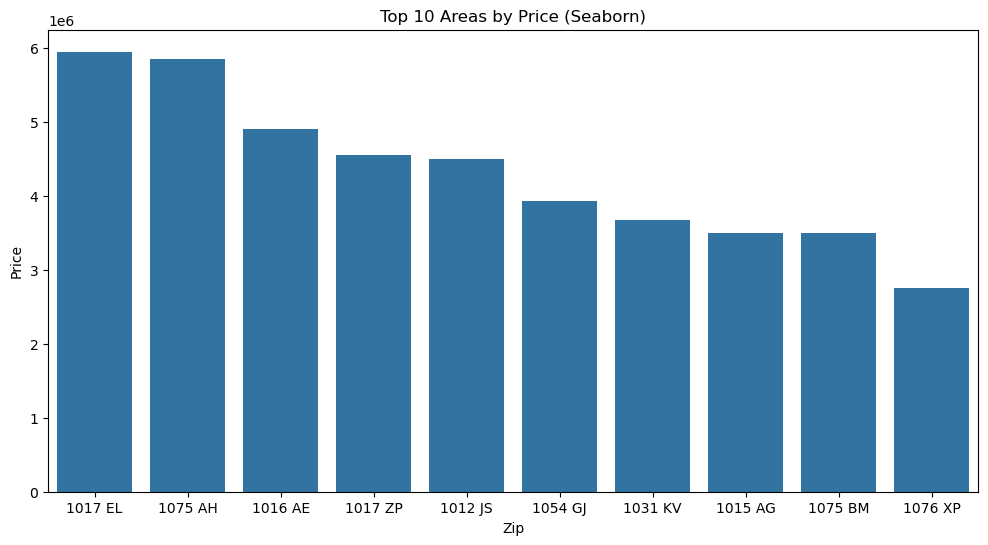

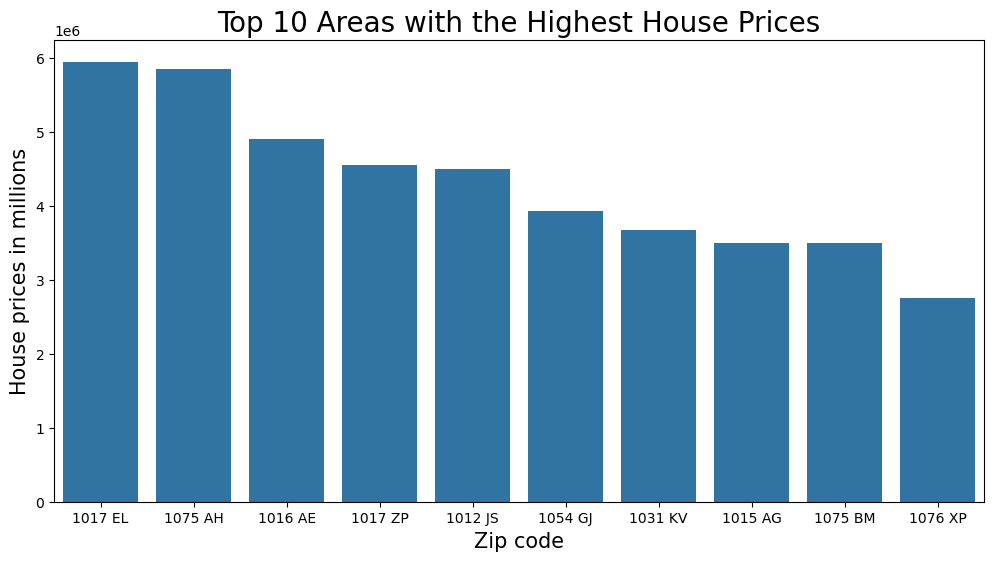

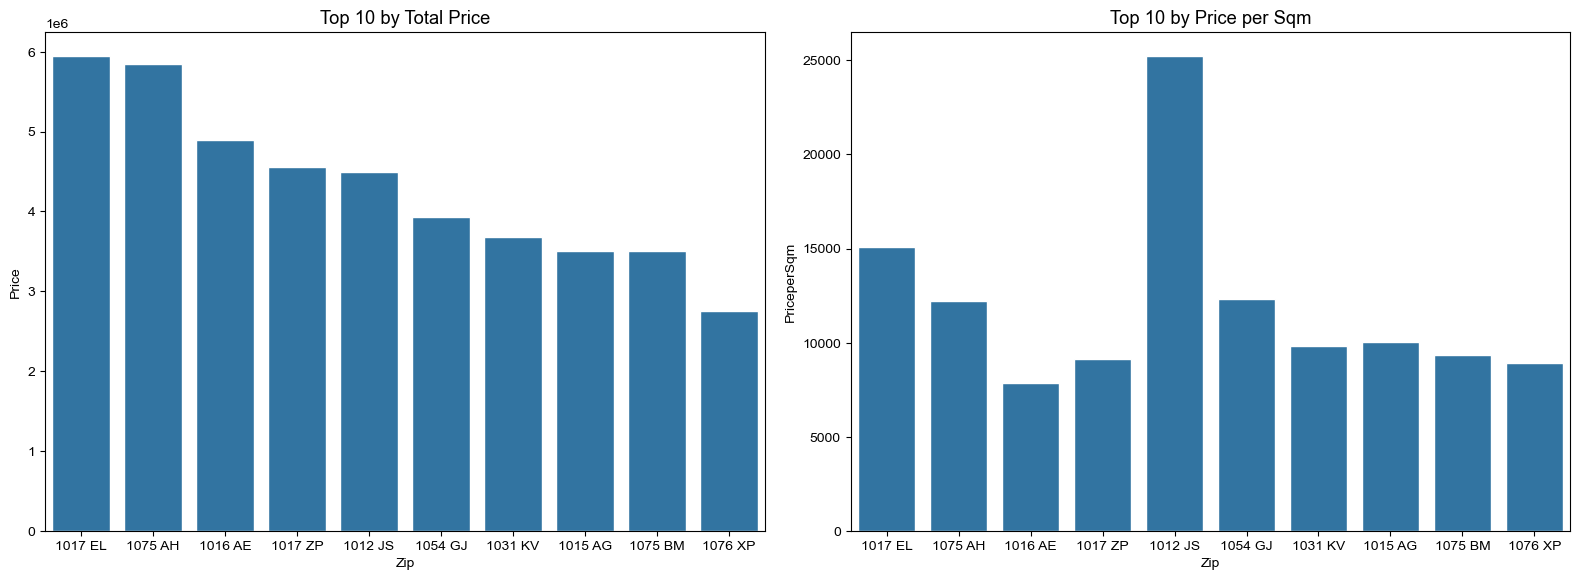

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

data_top10 = houseprices_sorted[0:10]

# Case 1: Basic seaborn barplot
plt.figure(figsize=(12,6))
sns.barplot(data=data_top10, x='Zip', y='Price')
plt.title('Top 10 Areas by Price (Seaborn)')
plt.show()

# Case 2: Advanced labels
plt.figure(figsize=(12,6))
ax = sns.barplot(data=data_top10, x='Zip', y='Price')
ax.set_xlabel('Zip code', fontsize=15)
ax.set_ylabel('House prices in millions', fontsize=15)
ax.set_title('Top 10 Areas with the Highest House Prices', fontsize=20)
plt.show()

# Case 3: View multiple perspectives
fig, ax = plt.subplots(1, 2, figsize=(16,6))
sns.set(font_scale=1.1)
ax1 = sns.barplot(data=data_top10, x='Zip', y='Price', ax=ax[0])
ax1.set_title('Top 10 by Total Price')
ax2 = sns.barplot(data=data_top10, x='Zip', y='PriceperSqm', ax=ax[1])
ax2.set_title('Top 10 by Price per Sqm')
plt.tight_layout()
plt.show()

> **Lưu ý sư phạm:**
- `seaborn` tự động tính trung bình khi trùng khóa—với dữ liệu đã tổng hợp, nên dùng mỗi `Zip` một dòng.

## 1.3 Phân tích đơn biến và hai biến

## Bài toán 1
Thực hiện các nhiệm vụ trong bài toán 1 để làm quen với các hàm và thư viện hỗ trợ phân tích 
dữ liệu đơn biến.

#### Nhiệm vụ 1. Phân tích đơn biến – Penguins
**Mục tiêu:** Khảo sát phân bố một biến số (`culmen_length_mm`) và phân bố tần suất một biến phân loại (`species`).

**Vì sao chạy?** Phát hiện phân bố lệch/tròn/cụm giá trị, và cấu trúc thành phần nhóm.

**Kỳ vọng kết quả:** Histogram, Countplot, Pie chart.

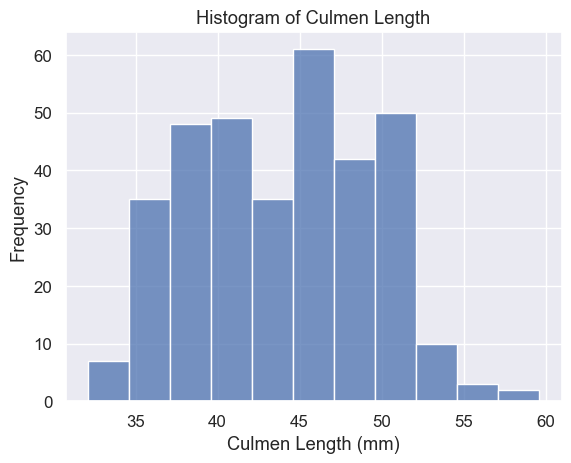

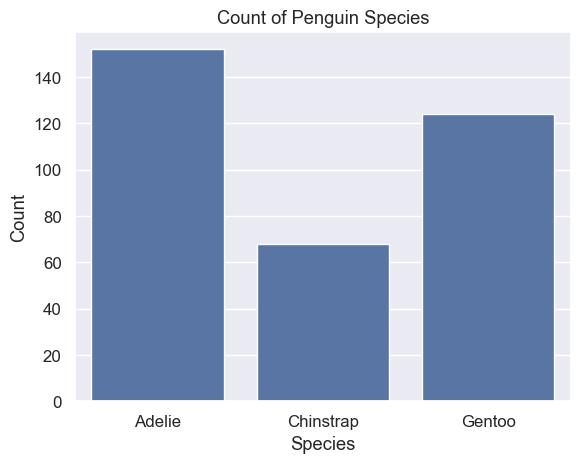

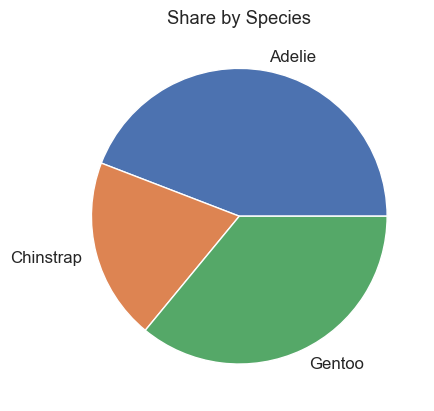

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

penguins_data = pd.read_csv("penguins_size.csv")
penguins_data = penguins_data[['species','culmen_length_mm']]

# Histogram (đơn biến số)
sns.histplot(data=penguins_data, x=penguins_data["culmen_length_mm"])
plt.title('Histogram of Culmen Length')
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Frequency')
plt.show()

# Bar chart (đơn biến phân loại)
sns.countplot(data=penguins_data, x=penguins_data['species'])
plt.title('Count of Penguin Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

# Pie chart (tỷ trọng theo species)
penguins_group = penguins_data.groupby('species').count().reset_index()
plt.pie(penguins_group["culmen_length_mm"], labels=penguins_group['species'])
plt.title('Share by Species')
plt.show()

> **Lưu ý sư phạm:**
- Với phân loại, `countplot` thường dễ đọc hơn `pie` khi có nhiều nhóm.
- Nếu có NA trong `culmen_length_mm`, cần `dropna()` trước khi vẽ histogram.

#### Nhiệm vụ 2. Phân tích đơn biến – Housing Prices (Boxplot, Violin, Describe)
**Mục tiêu:** Dùng box/violin để nhìn nhanh median, IQR, ngoại lai; `describe()` để tóm tắt số liệu.

**Vì sao chạy?** Box/violin giàu thông tin hơn histogram về phân tán & ngoại lai.

**Kỳ vọng kết quả:** Biểu đồ box/violin rõ ràng và bảng `describe()`.

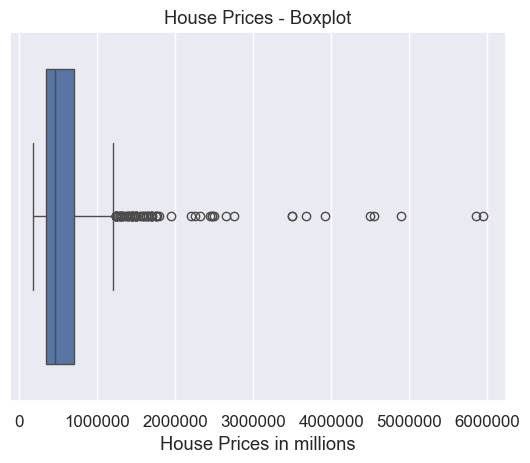

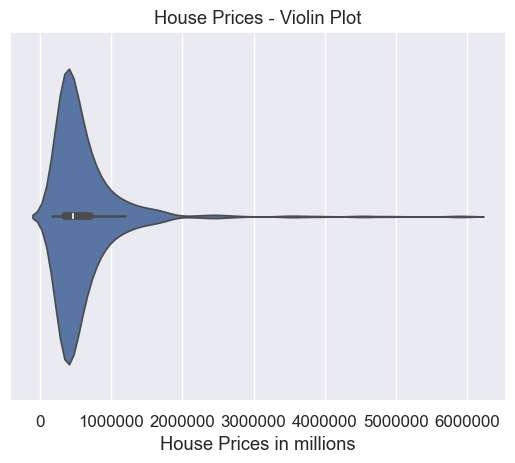

,Price,Area,Room
count,9.200000e+02,924.000000,924.000000
mean,6.220654e+05,95.952381,3.571429
std,5.389942e+05,57.447436,1.592332
min,1.750000e+05,21.000000,1.000000
25%,3.500000e+05,60.750000,3.000000
50%,4.670000e+05,83.000000,3.000000
75%,7.000000e+05,113.000000,4.000000
max,5.950000e+06,623.000000,14.000000


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

houseprices_data = pd.read_csv("HousingPricesData.csv")
houseprices_data = houseprices_data[['Zip','Price','Area','Room']]

# Boxplot
sns.boxplot(data=houseprices_data, x=houseprices_data["Price"])
plt.title('House Prices - Boxplot')
plt.xlabel('House Prices in millions')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Violin plot
sns.violinplot(data=houseprices_data, x=houseprices_data["Price"])
plt.title('House Prices - Violin Plot')
plt.xlabel('House Prices in millions')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Descriptive summary
display(houseprices_data.describe())

> **Lưu ý sư phạm:**
- Nếu thấy đuôi dài ở violin/box → phân bố lệch; cân nhắc log-transform trước khi mô hình.
- `ticklabel_format(style='plain')` hữu ích khi số quá lớn bị format khoa học.

### Bài toán 2 
Thực hiện các nhiệm vụ trong bài toán 2 để làm quen với việc phân tích hai biến với các hàm 
trong thư viện scikit-learn.


#### Nhiệm vụ 1. Phân tích hai biến – Penguins (Scatter, Crosstab, Pivot, Pairplot)
**Mục tiêu:** Khám phá mối liên hệ giữa hai biến số và giữa số–phân loại.

**Vì sao chạy?** Giúp dự đoán được chiều hướng quan hệ (tương quan, tuyến tính, cụm,...).

**Kỳ vọng kết quả:** Scatterplot, bảng tần suất chéo, pivot trung bình theo nhóm, pairplot tổng quan.

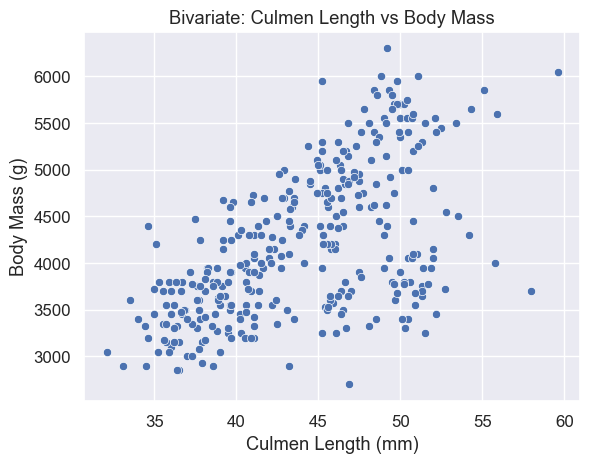

sex,.,FEMALE,MALE
species,,,
Adelie,0,73,73
Chinstrap,0,34,34
Gentoo,1,58,61


C:\Users\phuoc\AppData\Local\Temp\ipykernel_3284\116290161.py:22: FutureWarning: The provided callable <function mean at 0x00000210624C45E0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  display(pd.pivot_table(penguins_data,


,culmen_length_mm
species,
Adelie,38.823973
Chinstrap,48.833824
Gentoo,47.542500


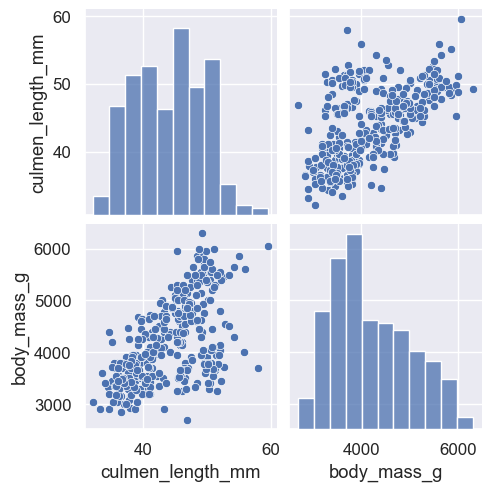

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

penguins_data = pd.read_csv("penguins_size.csv")
penguins_data = penguins_data[['species','culmen_length_mm','body_mass_g','sex']].dropna()

# Scatter: 2 biến số
sns.scatterplot(data=penguins_data,
                x=penguins_data["culmen_length_mm"],
                y=penguins_data['body_mass_g'])
plt.title('Bivariate: Culmen Length vs Body Mass')
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

# Crosstab: species x sex
display(pd.crosstab(index=penguins_data['species'], columns=penguins_data['sex']))

# Pivot: mean culmen_length_mm by species
display(pd.pivot_table(penguins_data,
                       values='culmen_length_mm',
                       index='species',
                       aggfunc=np.mean))

# Pairplot: cái nhìn tổng quan các cặp biến
sns.pairplot(data=penguins_data[['culmen_length_mm','body_mass_g']].dropna())
plt.show()

> **Lưu ý sư phạm:**
- Với scatter, quan sát **xu hướng** (tăng/giảm), **độ phân tán**, **ngoại lai**.
- `crosstab` hữu ích cho báo cáo tần suất; `pivot_table` giúp tổng hợp số liệu theo nhóm.

#### Nhiệm vụ 2. EDA tự động – ydata_profiling & D-Tale
**Mục tiêu:** Tạo báo cáo EDA tự động nhanh (profiling) và giao diện khám phá dữ liệu tương tác.

**Vì sao chạy?** Tiết kiệm thời gian tổng quan dữ liệu, phát hiện vấn đề (thiếu, ngoại lai, trùng...).

**Kỳ vọng kết quả:**
- Tệp HTML báo cáo tổng quan: phân phối, tương quan, cảnh báo chất lượng dữ liệu.
- Giao diện web của D-Tale để lọc/sắp xếp/biểu đồ nhanh.

> **Lưu ý:** Cần cài `ydata_profiling` và `dtale`. Chạy cell cài đặt ở dưới nếu thiếu.

In [ ]:
# Cài mamba vào base
conda install -n base -c conda-forge mamba -y

# Tạo môi trường mới và cài gói bằng mamba
mamba create -n eda python=3.10 ydata-profiling dtale -c conda-forge -y

# Kích hoạt và chạy Jupyter
conda activate eda
jupyter notebook


In [37]:
%pip install --user ydata-profiling dtale


  Using cached ydata_profiling-4.17.0-py2.py3-none-any.whl.metadata (22 kB)
  Using cached dtale-3.18.2-py2.py3-none-any.whl.metadata (16 kB)
  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached minify_html-0.16.4-cp313-cp313-win_amd64.whl.metadata (18 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached phik-0.12.5.tar.gz (621 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached multimethod-1.12-py3-none-any.whl.metadata (9.6 kB)
  Using cached typeguard-4.4.4-py3-none-any.whl.metadata (3.3 kB)
  Using cached ImageHash-4.3.1-py2.py

  error: subprocess-exited-with-error
  
  exit code: 1
  
  [18 lines of output]
  *** scikit-build-core 0.11.6 using CMake 4.1.0 (wheel)
  *** Configuring CMake...
  loading initial cache file C:\Users\phuoc\AppData\Local\Temp\tmp_778usbl\build\CMakeInit.txt
  -- Building for: NMake Makefiles
  CMake Error at CMakeLists.txt:5 (project):
    Running
  
     'nmake' '-?'
  
    failed with:
  
     no such file or directory
  
  
  CMake Error: CMAKE_CXX_COMPILER not set, after EnableLanguage
  -- Configuring incomplete, errors occurred!
  
  *** CMake configuration failed
  [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for phik
ERROR: Failed to build installable wheels for some pyproject.toml based projects (phik)


In [42]:
conda install -c conda-forge ydata-profiling dtale


Note: you may need to restart the kernel to use updated packages.


'E:\Anaconda' is not recognized as an internal or external command,
operable program or batch file.


In [38]:
# Cài thư viện phục vụ cho EDA tự động
!pip install ydata-profiling dtale --quiet

  error: subprocess-exited-with-error
  
  exit code: 1
  
  [18 lines of output]
  *** scikit-build-core 0.11.6 using CMake 4.1.0 (wheel)
  *** Configuring CMake...
  loading initial cache file C:\Users\phuoc\AppData\Local\Temp\tmppspomn6n\build\CMakeInit.txt
  -- Building for: NMake Makefiles
  CMake Error at CMakeLists.txt:5 (project):
    Running
  
     'nmake' '-?'
  
    failed with:
  
     no such file or directory
  
  
  CMake Error: CMAKE_CXX_COMPILER not set, after EnableLanguage
  -- Configuring incomplete, errors occurred!
  
  *** CMake configuration failed
  [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for phik
ERROR: Failed to build installable wheels for some pyproject.toml based projects (phik)


In [39]:
from ydata_profiling import ProfileReport
import dtale

ModuleNotFoundError: No module named 'ydata_profiling'

In [ ]:
import pandas as pd
from ydata_profiling import ProfileReport

marketing_data = pd.read_csv("marketing_campaign.csv")

# Tạo báo cáo EDA tự động (HTML). Mở file trong trình duyệt sau khi chạy.
profile = ProfileReport(marketing_data)
profile.to_file("Reports/profile_output.html")
print("Report saved to Reports/profile_output.html")

In [ ]:
import pandas as pd
import dtale

marketing_data = pd.read_csv("marketing_campaign.csv")

# Mở giao diện D-Tale trong trình duyệt (chạy cục bộ)
dtale.show(marketing_data).open_browser()

#### Bài tập thực hành 1
Tìm hiểu các tính năng và cách sử dụng sản phẩm SweetViz (https://pypi.org/project/sweetviz) áp dụng
trên tập dữ liệu Marketing Campaign

#### Bài tập thực hành 2
Tìm hiểu các tính năng và cách sử dụng sản phẩm AutoViz (https://pypi.org/project/autoviz) áp dụng trên 
tập dữ liệu Marketing Campaign

---
### Tổng kết
- EDA bắt đầu từ **hiểu dữ liệu** (thống kê mô tả) → **làm sạch** → **trực quan hóa** → **phân tích quan hệ** → (tùy chọn) **EDA tự động**.
- Trước khi mô hình, hãy đảm bảo dữ liệu đã được xử lý vấn đề thiếu/ngoại lai/kiểu dữ liệu.